# <img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Trabajo Practico 1

Autores: Lopez Cruz Juan Carlos y Nahuel Siles

Diseñar un filtro pasaaltos **Chebyshev** que cumpla con la siguiente plantilla:

# <img src="./plantilla_tp1.png" /> 

# Análisis y Simulación

1. Obtener el orden del filtro y hallar la función transferencia total.
2. Obtener la transferencia de la red circuital a implementar.
3. Simulación numérica/simbólica de la función transferencia en Python.
4. Simulación circuital. Incluya el modelo real del OPAMP.

# Implementación y armado:

1. Diseñar el Layout del PCB.
2. Usar conectores, headers o borneras para alimentar el filtro, introducir la señal de entrada, medir la señal de entrada y salida ( test points )
3. Utilizar un zócalo DIP 14 para colocar el OPAMP.
4. Incluir resistores variables ( presets / trimmer ) o bien resistores fijos con tolerancias del 1%.
5. Agregar capacitores de bypass en la alimentacion del Amplificador. Agregar capacitor electrolítico o poliéster de 1 µF a 100 µF con otro cerámico de 100 nF a 470 nF en paralelo para reducir el ruido de la fuente.

# Medicion

# <img src="./forma_de_medicion_tp1.png" /> 

1. Verificar visualmente y con el multímetro que el circuito no tiene cortocircuitos y que los componentes estén correctamente soldados.
2. Utilice la limitación de corriente de la fuente en algunas decenas de mA. Para ello se debe poner en corto los bornes de + y - a una tensión baja por ejemplo 1 V. De esta manera el equipo entra en modo CC ( corto circuito ) y se puede setear el nivel de corriente.
3. Setear la tensión de la fuente. Utilice un multímetro para ajustar la tensión de la fuente. Finalmente alimente su circuito. Tenga en cuenta que la medición mejora para niveles más altos de fuente.
4. Verifique las puntas del osciloscopio. Utilice la señal de prueba tanto en el canal 1 como 2 para ajustar la respuesta temporal visualizada. Verifique el valor de AC y periodo de esta señal de prueba con los medidores del DSO.
5. Calibre una señal senoidal en el generador a un nivel que optimice la medición en la banda de paso de valor medio nulo con el generador. Tenga en cuenta que el filtro puede generar sobretensiones a la salida.
6. Desenergice el circuito si así estuviera y conecte el integrado. Conecte la alimentación nuevamente y el generador de entrada. Verifique que el DSO tenga señal a la salida. Debe ser de la misma forma ( sin distorsión ) que la entrada con una cierta fase y alguna diferencia de amplitud probablemente.
7. Llegado a este punto está en condiciones de realizar un barrido con frecuencia.

## Resolucion:

### Normalizacion de la plantilla

Primeramente procedemos a normalizar nuestra plantilla, para ello tomamos como norma de frecuencia a $\Omega_\omega = \omega_p = 2\pi f_p$ por lo que queda de la siguiente manera:

* $\omega_{p_n} = \frac{\omega_p}{\omega_p} = 1$
* $\omega_{s_n} = \frac{\omega_s}{\omega_p} = \frac{f_s}{f_p} = \frac{100Hz}{300Hz} = \frac{1}{3} = 0.33$

### Transformacion de la plantilla

Ahora procedemor a transformar nuestra plantilla pasa alto a una pasa bajos, para ello calculamos nuestras $\omega_{p_{LP}}$ y $\omega_{s_{LP}}$.

* $\omega_{p_{LP}} = \frac{1}{\omega_{p_n}} = 1$
* $\omega_{s_{LP}} = \frac{1}{\omega_{s_n}} = \frac{1}{\frac{1}{3}} = 3$

### Obtencion de la Transferencia

$$
\alpha_{\text{max}} = -20 \log \left( \frac{1}{\sqrt{1 + \xi^2 \, \omega_p^{2n}}} \right)
$$

Si $\omega = \omega_p = 1$:

$$
\alpha_{\text{max}} = -20 \log \left( \frac{1}{\sqrt{1 + \xi^2}} \right) = -20 \left( -\frac{1}{2} \log(1 + \xi^2) \right)
$$

$$
\alpha_{\text{max}} = 10 \log(1 + \xi^2)
$$

Como nuestra $\alpha_{\text{max}} = 1$ nos queda que $\xi^2 = 10^{0.1\alpha_{\text{max}}} - 1 = 10^{0.1*1} - 1 = 0.2589$, por lo tanto nos queda que

$$
\xi = \sqrt{0.2589} = 0.5088
$$

Ahora calcularemos n.

$$
\alpha_{\min} = 10 \log \left(1 + \xi^2 \cosh^2\left(n \cosh^{-1}(w)\right)\right)
$$

$$
\frac{\alpha_{\min}}{10} = \log \left(1 + \xi^2 \cosh^2\left(n \cosh^{-1}(w)\right)\right)
$$

$$
10^{\frac{\alpha_{\min}}{10}} = 1 + \xi^2 \cosh^2\left(n \cosh^{-1}(w)\right)
$$

$$
10^{\frac{\alpha_{\min}}{10}} - 1 = \xi^2 \cosh^2\left(n \cosh^{-1}(w)\right)
$$

$$
\frac{10^{\frac{\alpha_{\min}}{10}} - 1}{\xi^2} = \cosh^2\left(n \cosh^{-1}(w)\right)
$$

$$
\sqrt{\frac{10^{\frac{\alpha_{\min}}{10}} - 1}{\xi^2}} = \cosh\left(n \cosh^{-1}(w)\right)
$$

$$
\cosh^{-1}\left(\sqrt{\frac{10^{\frac{\alpha_{\min}}{10}} - 1}{\xi^2}}\right) = n \cosh^{-1}(w)
$$

$$
n = \frac{\cosh^{-1}\left(\sqrt{\frac{10^{\frac{\alpha_{\min}}{10}} - 1}{\xi^2}}\right)}{\cosh^{-1}(w)}
$$

Como sabemos que $\xi^2 = 10^{0.1\alpha_{\text{max}}} - 1$ nos queda de la siguiente manera

$$
n = \frac{\cosh^{-1}\left(\sqrt{\frac{10^{0.1\alpha_{\min}} - 1}{10^{0.1\alpha_{\text{max}}} - 1}}\right)}{\cosh^{-1}(w)}
$$

Ya con la formula despejada solo nos queda reemplazar los valores.

$$
n = \frac{\cosh^{-1}\left(\sqrt{\frac{10^{0.1\cdot30dB} - 1}{10^{0.1\cdot1dB} - 1}}\right)}{\cosh^{-1}(3)}
$$

$$
n = 2.73
$$

Como n = 2.73 tiene que ser un numero natural, redondeamos para arriba para asi cumplir con la condicion de la plantilla, por lo que nos queda que n = 3.

### Obtencion de la transferencia normalizada

Para este desarrollo tendremos en cuenta la siguiente identidad:

$$
\left| T(j\omega) \right|^2 = T(j\omega) \cdot T(-j\omega) = T(s) \cdot T(-s)\big|_{s = j\omega}
$$

Ya con esto definido empezamos nuestro desarrollo.

$$
|H(j\omega)|^2 = H(j\omega)\cdot H(-j\omega) = H(s)H(-s)
$$

$$
|H(j\omega)|^2 = \frac{1}{1 + \xi^2 C_n^2(\omega)}
$$

Para trabajar con el polinomio de Chebishev sabemos que $C_n^2(\omega) = 2\omega C_{n-1}(\omega) - C_{n-2}(\omega)$ donde $C_0(\omega) = 1$ y $C_1(\omega) = \omega$, con esto procedemos a calcular el polinomio de Chebyshev

$$
C_2(\omega) = 2\omega^2 - 1
$$

$$
C_3(\omega) = 2\omega(2\omega^2 -1) - \omega = 4\omega^3 - 3\omega
$$

Ahora sustituimos lo obtenido

$$
|H(j\omega)|^2 = \frac{1}{1 + \xi^2 (4\omega^3 - 3\omega)^2}
$$

$$
|H(j\omega)|^2 =\frac{1}{1 + \xi^2 ((4\omega^3)^2 -2\cdot4\omega^3\cdot3\omega + (3\omega)^2}
$$

$$
|H(j\omega)|^2 =\frac{1}{1 + \xi^2 (16\omega^6 -24\omega^4 + 9\omega^2}
$$

$$
|H(j\omega)|^2 =\frac{1}{1 + \xi^2 16\omega^6 -\xi^2 24\omega^4 + \xi^2 9\omega^2}
$$

Como $\omega = \frac{s}{j}$ nos queda que:

$$
|H(s)|^2 =\frac{1}{1 + \xi^2 16(\frac{s}{j})^6 -\xi^2 24\frac{s}{j}^4 + \xi^2 9\frac{s}{j}^2}
$$

$$
|H(s)|^2 =\frac{1}{1 - \xi^2 16s^6 -\xi^2 24s^4 - \xi^2 9s^2}
$$

Usaremos la identidad mosttrada anteriormente para obtener nuestra transferencia.

$$
\left| T(j\omega) \right|^2 = T(j\omega) \cdot T(-j\omega) = T(s) \cdot T(-s)\big|_{s = j\omega}
$$

$$
\Rightarrow |H(s)|^2 =\frac{1}{1 - \xi^2 16s^6 -\xi^2 24s^4 - \xi^2 9s^2} = \frac{1}{s^3 \cdot a + s^2 \cdot b + s \cdot c + d}\frac{1}{-s^3 \cdot a + s^2 \cdot b - s \cdot c + d}
$$

Procedemos a igualar los coeficientes del denominador.

$$
-a^2 = -16\xi^2 \Rightarrow a = 4\xi = 2.0352
$$

$$
-24\xi^2 = b^2 - 2ac \quad (1)
$$

$$
-9\xi^2 = 2bd - c^2 \Rightarrow c = \sqrt{2bd + 9\xi^2} \quad (2)
$$

$$
d^2 = 1 \Rightarrow d = 1
$$

$(2) \Rightarrow (1)$

$$
-24\xi^2 = b^2 - 2a \cdot \sqrt{2b + 9\xi^2}
$$

$$
b^2 + 24\xi^2 = 2a \cdot \sqrt{2b + 9\xi^2}
$$

$$
(b^2)^2 + 2 \cdot 24\xi^2 \cdot b^2 + (24\xi^2)^2 = 64\xi^2 (2b + 9\xi^2)
$$

$$
b^4 + 48\xi^2 \cdot b^2 + 576\xi^4 = 128\xi^2 \cdot b + 576\xi^4
$$

$$
b^4 + 48\xi^2 \cdot b^2 - 128\xi^2 \cdot b = 0
$$

$$
b^3 + 48\xi^2 b - 128\xi^2 = 0
\Rightarrow b = 2.0116
$$

$$
\Rightarrow c = \sqrt{2bd + 9\xi^2} = c = \sqrt{2 \cdot 2.0116 + 9\xi^2}
$$

$$
c = 2.5205
$$

Con los coeficientes calculados podemos obtener nuestra transferencia.

$$
H(s) = \frac{1}{s^3 \cdot a + s^2 \cdot b + s \cdot c + d} = \frac{1}{s^3 \cdot 2.0352 + s^2 \cdot 2.0116 + s \cdot 2.5205 + 1}
$$

$$
H(s) = \frac{0.4913}{s^3 + s^2 \cdot 0.9884 + s \cdot 1.2384 + 0.4913}
$$

Ahora usaremo python para corroborar nuestro analisis

In [3]:
# Módulos numéricos y de funciones científicas
import numpy as np
from scipy import signal as sig
import sympy as sp
from IPython.display import display, Math

# Módulos para los gráficos
import matplotlib as mpl
from matplotlib import pyplot as plt

# Funciones de PyTC2
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys, tf2sos_analog, pretty_print_SOS
from pytc2.general import print_latex, print_subtitle, a_equal_b_latex_s

#Tamaño de los gráficos
fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi

fig_font_size = 11

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

In [5]:
# Descomentar en caso de que no esten importados

# import matplotlib.pyplot as plt
# import numpy as np
# import scipy.signal as sig

"""Grafica una o varias funciones de transferencia marcando puntos específicos en frecuencia.

    Parámetros:
    - TS: Una función de transferencia o lista [H1, H2, ...]
    - puntos: Frecuencia (float) o lista de frecuencias [w1, w2, ...] a marcar
    - labels: Lista de nombres para identificar cada curva en la leyenda
    - xlim, ylim: Tuplas para los límites de los ejes, ej: ylim=(-30, 15)
"""

import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sig


def graficar_bode_avanzado(TS, *, puntos=None, labels=None, xlim=None, ylim=None):

    # 1. Asegurar que TS sea una lista
    if not isinstance(TS, (list, tuple)):
        TS_list = [TS]
    else:
        TS_list = TS

    # Normalizar parámetro puntos
    if puntos is not None and isinstance(puntos, (int, float)):
        puntos = [puntos]
    
    # 2. Graficar cada sistema en la misma figura
    for i, sistema in enumerate(TS_list):
        _, axes = bodePlot(sistema, fig_id="one")

        # Asignar label a la curva si se proporcionó
        nombre_sistema = (
            labels[i] if (labels and i < len(labels)) else f"TS {i+1}"
        )
        axes[0].lines[-1].set_label(nombre_sistema)

        # 3. Marcar los puntos para cada sistema
        if puntos is not None:
            num, den = sistema.num, sistema.den
            _, h = sig.freqs(num, den, worN=puntos)
            mag_points = 20 * np.log10(np.abs(h))
            
            for w_p, mag_p in zip(puntos, mag_points):
                # Punto rojo y líneas punteadas
                axes[0].plot(w_p, mag_p, "ro")
                axes[0].axvline(w_p, linestyle="--", alpha=0.5)
                axes[0].axhline(mag_p, linestyle="--", alpha=0.5)

                axes[0].annotate(
                    f"({w_p:.3f}, {mag_p:.2f} dB)",
                    (w_p, mag_p),
                    xytext=(8, 5),
                    textcoords="offset points",
                    fontsize=8,
                )

    # 4. Ajuste de límites
    if xlim is not None:
        axes[0].set_xlim(xlim)

    if ylim is not None:
        axes[0].set_ylim(ylim)

    # 5. Mostrar Leyenda de curvas
    axes[0].legend(loc="upper right", framealpha=0.9)
    
    plt.show()

In [9]:
wc = 1
n = 3
alpha_max = 1

num, den=sig.cheby1(n,alpha_max,wc, analog=True)
s = sp.symbols('s')

num=np.round(num,4)
numP=sp.Poly(num,s)
den=np.round(den,4)
denP=sp.Poly(den,s)

Ts=sp.simplify(numP)/sp.simplify(denP)
display(Math(r'T(s) = ' + sp.latex(Ts)))

<IPython.core.display.Math object>

Podemos notar que es igual a la transferecia calculada anteriormente

### Construccion de la Transferencia en secciones

Podemos observar que para construir nuestra transferecia usaremos una seccion de segundo orden y una de primer orden, por lo que procedemos a calcular los polos de nuestra transferecia.

In [11]:
Tfsos = tf2sos_analog(num , den)

print_latex(a_equal_b_latex_s('T_{hp}(s)', pretty_print_SOS(Tfsos, displaystr=False)))


<IPython.core.display.Math object>

Una vez calculado nuestro coeficientes de nuetra transfereciaprocedemos a armar la misma.

$$
T(s)= \frac{0.4942}{s + 0.4942} \frac{K_1 \cdot 0.9942}{s^2 + s \cdot 0.4942 + 0.9942}
$$

Ahora procedemos a calcular la ganancia de la seccion de segundo orden.

$$
0.4942\cdot(K_1\cdot0.9942) = 0.4913
$$

$$
K_1 = 1
$$

Ahora reemplazamos las ganancias calculadas en nuestra transferencia.

$$
T(s)= \frac{0.4942}{s + 0.4942} \frac{1 \cdot 0.9942}{s^2 + s \cdot 0.4942 + 0.9942}
$$

### Verificacion de la plantilla pasa bajo

Procedemos a verificar la transferencia obtenida

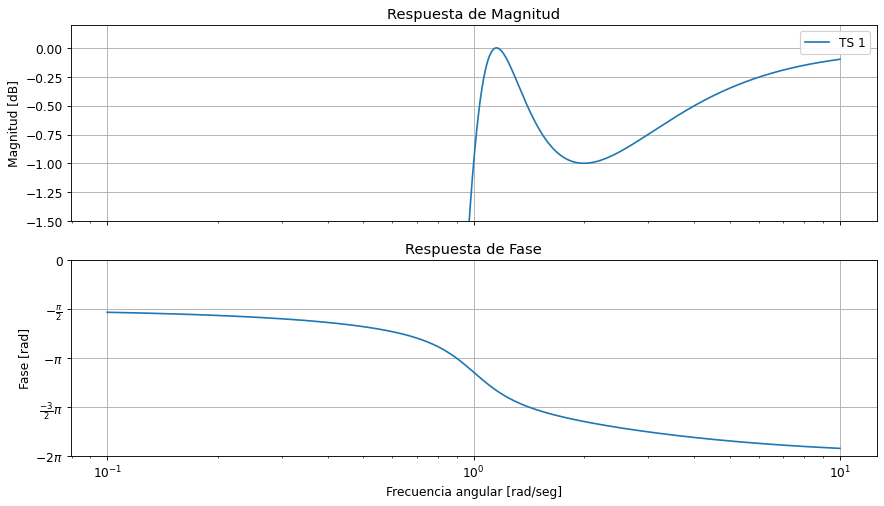

In [29]:
#Función trasnferencia
TS=sig.TransferFunction(num,den)

graficar_bode_avanzado(TS, ylim = (-1.5, 0.2))

Podemos observar que nuestra transferencia oscila entre 0 y -1dB a lo largo de la banda de paso, cumpliendo con el $\alpha_{max}$ propuesto.

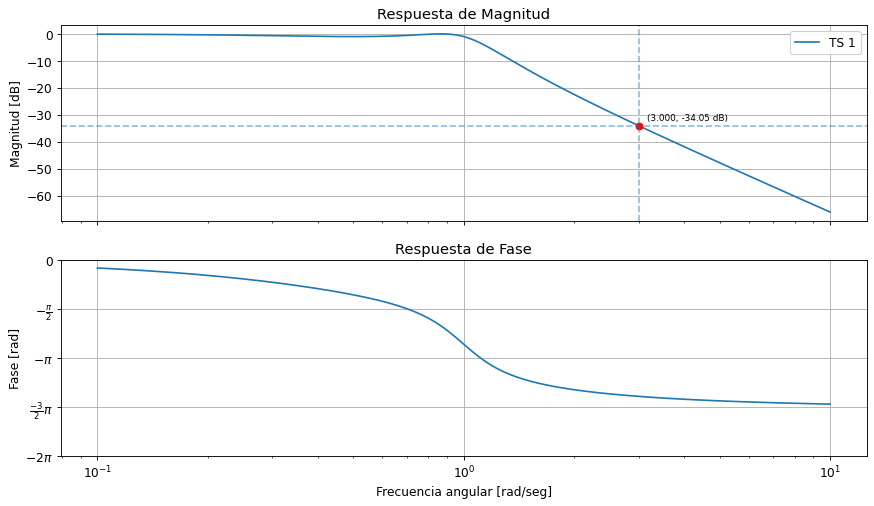

In [19]:
graficar_bode_avanzado(TS, puntos = 3)

Vemos también que para $\omega = 3$ hubo una caida mayor a 30dB por lo que se cumple la atenuacion minima de nuestra plantilla.

### Transformacion de la transferencia

Con nuestra verificada procedemos a transformar nuestra transferecia pasa bajos a una pasa altos usando el siguiente nucleo de transformacion.

$$
p = K(s) = \frac{1}{s}
$$

Usando el nucleo nos queda la transferencia de la siguiente forma.

$$
T_{HP}(s)= \frac{0.4942}{\frac{1}{s} + 0.4942} \frac{1 \cdot 0.9942}{(\frac{1}{s})^2 + \frac{1}{s} \cdot 0.4942 + 0.9942}
$$

$$
T_{HP}(s)= \frac{s \cdot 0.4942}{1 + s \cdot 0.4942} \frac{s^2 \cdot 0.9942}{1 + s \cdot 0.4942 + s^2 \cdot 0.9942}
$$

$$
T_{HP}(s)= \frac{s}{s + 2.0234} \frac{s^2}{s^2 + s \cdot 0.497 + 1.0058}
$$

### Verificacion de la plantilla pasa altos

Procedemos e verificar nuestra transferencia pasa altos

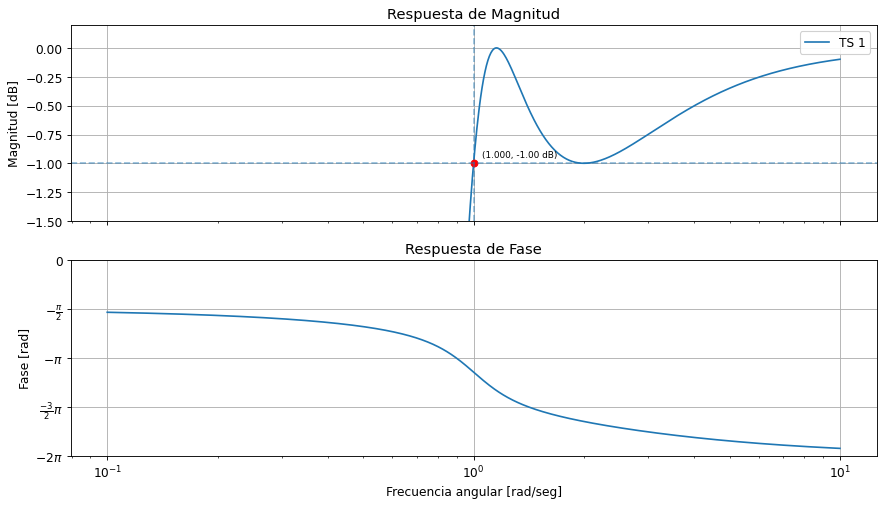

In [21]:
# Cargamos la funcion transferencia como vectores de sus coeficientes.

num_1 = np.array([ 1, 0])
den_1 = np.array([ 1, 2.0234])

num_2 = np.array([ 1, 0, 0])
den_2 = np.array([ 1, 0.497, 1.0058])

num = np.polymul(num_1, num_2)
den = np.polymul(den_1, den_2)

H1 = sig.TransferFunction( num, den )

graficar_bode_avanzado(H1, puntos = 1, ylim = (-1.5, 0.2))

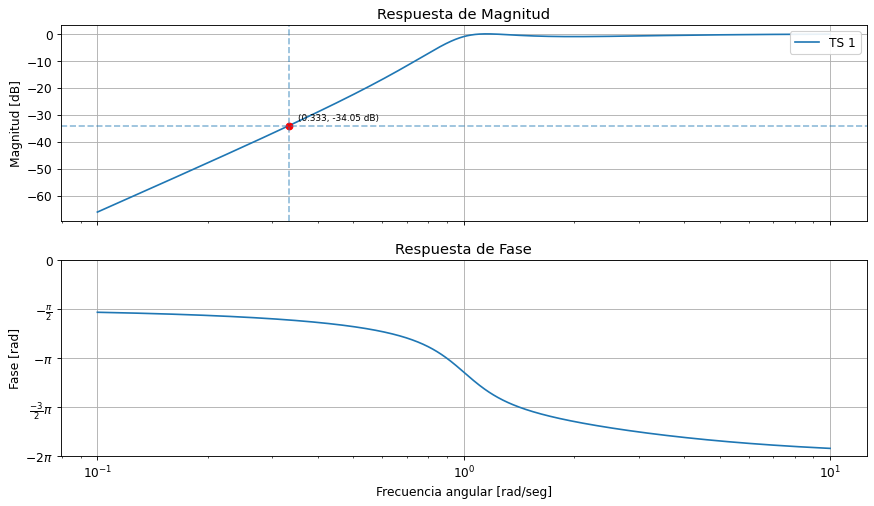

In [31]:
graficar_bode_avanzado(H1, puntos = 1/3)

Podemos observar, que igual a la transferencia pasa bajos, se cumple los $\alpha_{max}$ y $\alpha_{min}$

### Seleccion del circuito

Ya calculado nuestra transferencia pasa altos nos queda seleccionar que el circuito a usar, para ello proponemos usar el circuito Ackerberg–Mossberg usando el concepto de voltage fordware para conseguir un pasa altos de segundo orden a su salida.

En los filtros activos, se pueden crear nuevos ceros de transmisión inyectando la entrada en cualquier nodo de tierra virtual, esta forma de generación de ceros es aplicable al Ackerberg–Mossberg, para ello se propone usar el siguiente circuito.

# <img src="./Ackerberg–Mossberg_con_VF.png"/> 

Usaremos a $V_2$ como nuestra salida, con esto comenzamos a plantear las ecuaciones.

$$
V_1(s \cdot aC + K \cdot G) + V_2(sC + \frac{G}{Q}) + V_6 \cdot G = 0
$$

$$
V_1 \cdot cG + V_2 \cdot G + V_7 \cdot sC = 0
$$

$$
V_6 \cdot G + V_7 \cdot G + V_1 \cdot bG = 0
$$

Aqui defiremos a $\omega_0 = \frac{1}{CR}$ quedando nuestras ecuaciones de la siguiente manera.

$$
V_1(s \cdot a + K \cdot \omega_0) + V_2(s + \frac{\omega_0}{Q}) + V_6 \cdot \omega_0 = 0
$$

$$
V_1 \cdot c\omega_0 + V_2 \cdot \omega_0 + V_7 \cdot s = 0
$$

$$
V_6 + V_7 + V_1 \cdot b = 0 
$$

Con las ecuaciones ya definidas procedemos a encontrar nuestra funcion transferencia.

$$
\begin{aligned}
(1): &\hspace{5em} V_6 = - V_7 - V_1 \cdot b  \\
\\
(2): &\hspace{5em} V_7 = - V_1 \cdot \frac{c\omega_0}{s} - V_2 \cdot \frac{\omega_0}{s} \\
\\
(2) \Rightarrow (1) = (3): &\hspace{5em} V_6 = - (- V_1 \cdot \frac{c\omega_0}{s} - V_2 \cdot \frac{\omega_0}{s}) - V_1 \cdot b \Rightarrow V_6 = V_1(\frac{c\omega_0}{s} - b) + V_2 \cdot \frac{\omega_0}{s} \\
\\
(4): &\hspace{5em} V_1(s \cdot a + K \cdot \omega_0) + V_2(s + \frac{\omega_0}{Q}) + V_6 \cdot \omega_0 = 0 \\
\\
(3) \Rightarrow (4) = (5): &\hspace{5em} V_1(s \cdot a + K \cdot \omega_0) + V_2(s + \frac{\omega_0}{Q}) + (V_1(\frac{c\omega_0}{s} - b) + V_2 \cdot \frac{\omega_0}{s}) \cdot \omega_0 = 0 \\
\\
\end{aligned}
$$

Desarrolamos la Ec. (5).

$$
V_1(s \cdot a + K \cdot \omega_0) + V_2(s + \frac{\omega_0}{Q}) + (V_1(\frac{c\omega_0}{s} - b) + V_2 \cdot \frac{\omega_0}{s}) \cdot \omega_0 = 0
$$

$$
V_1(s \cdot a + K \cdot \omega_0) + V_2(s + \frac{\omega_0}{Q}) + V_1(\frac{c\omega_0^2}{s} - b \cdot \omega_0) + V_2 \cdot \frac{\omega_0^2}{s} = 0
$$

$$
V_2(s + \frac{\omega_0}{Q} + \frac{\omega_0^2}{s}) = - V_1(s \cdot a + K \cdot \omega_0 + \frac{c\omega_0^2}{s} - b \cdot \omega_0)
$$

$$
\frac{V_2}{V_1} = -\frac{\frac{s^2 \cdot a + s \cdot K \cdot \omega_0 + c\omega_0^2 - s \cdot b \cdot \omega_0}{\cancel s}}{\frac{s^2 \cdot Q + s \cdot \omega_0 + \omega_0^2 \cdot Q}{\cancel s \cdot Q}}
$$

$$
\frac{V_2}{V_1} = - \frac{s^2 \cdot a + s(K \cdot \omega_0 - b \cdot \omega_0) + c\omega_0^2}{\frac{\cancel Q \cdot (s^2 + s \frac{\omega_0}{Q} + \omega_0^2)}{\cancel Q}}
$$

$$
\frac{V_2}{V_1} = - \frac{s^2 \cdot a + s \cdot \omega_0 (K - b) + c\omega_0^2}{s^2 + s \frac{\omega_0}{Q} + \omega_0^2}
$$

Con la funcion transferencia ya definida elegimos las siguientes condiciones para conseguir un filtro pasa altos.

* $b = 0$

* $c = 0$

* $k = 0$

* $a = 1$

Con estas condiciones logramos tener una funcion transferencia que se asemeja a la plantilla propuesta anteriormente, quedando el circuito de la siguiente manera.

# <img src="./circuito_pasa_alto_Ackerberg–Mossberg_plantilla.png"/>

$$
\frac{V_2}{V_1} = - \frac{s^2}{s^2 + s \frac{\omega_0}{Q} + \omega_0^2}
$$

Para la seccion usaremos el siguiente circuito.

# <img src="./circuito_pasa_alto_CR.png"/>

La cual nos da la siguiente funcion transferencia.

$$
V_o = V_i \cdot \frac{R}{R + \frac{1}{s \cdot C}}
$$

$$
\frac{V_o}{V_i} = \frac{s \cdot RC}{s \cdot RC + 1} = \frac{s \cdot \cancel {RC}}{\cancel {RC} (s + \frac{1}{RC})}
$$

$$
\frac{V_o}{V_i} = \frac{s}{s + \frac{1}{RC}}
$$

Aqui definimos que $\omega_0 = \frac{1}{RC}$, por lo que nos queda de la siguiente forma.

$$
\frac{V_o}{V_i} = \frac{s}{s + \omega_0}
$$

Ya definido nuestros circuitos para la seccion de segundo orden y para la de primer orden, cascadeamos los mismos para conseguir nuestro circuito que cumple con los requisitos de la plantilla, quedando nuestro circuito final de la siguiente forma.

# <img src="./circuito_pasa_alto_plantilla.png"/>

De la cual obetenmos la sifuiente funcion transferencia.

$$
\frac{V_2}{V_1} = - \frac{s^2}{s^2 + s \frac{\omega_{0_1}}{Q} + \omega_{0_1}^2} \cdot \frac{s}{s + \omega_{0_2}}
$$

### Obtencion de los parametros $Q$, $\omega_{0_1}$ y $\omega_{0_2}$

Procederemos a calcular los valores de nuestros compoenentes, para ello tenemos que definir los valores de $Q$, $\omega_{0_1}$ y $\omega_{0_2}$, para ello tomaremos los valores de nuestra plantilla pasa altos calculado anteriormente.

$$
H(s) = \frac{s^2}{s^2 + s \frac{\omega_{0_1}}{Q} + \omega_{0_1}^2} \cdot \frac{s}{s + \omega_{0_2}} = \frac{s}{s + 2.0234} \frac{s^2}{s^2 + s \cdot 0.497 + 1.0058}
$$

Donde:

* $\omega_{0_1}^2 = 1.0058 \Rightarrow \omega_{0_1} = 1.0029$

* $\frac{\omega_{0_1}}{Q} = 0.497 \Rightarrow Q = \frac{\omega_{0_1}}{0.497} = \frac{1.0029}{0.497} \Rightarrow Q = 2.0179$

* $\omega_{0_2} = 2.0234$

### Obtencion de los componentes

Procedemos a calcular los valores de nuestra red circuital teniendo en cuenta los parametros calculados anteriormente.

Seccion de segundo orden:

$$
\omega_{0_1} = \frac{1}{RC}
$$

Donde si elegimos que C = 1 nos queda que $R = \frac{1}{\omega_{0_1}} = \frac{1}{1.0029} = 0.9971$

Seccion de primer orden:

$$
\omega_{0_1} = \frac{1}{R1 \cdot C}
$$

Donde si elegimos que C = 1 nos queda que $R1 = \frac{1}{\omega_{0_2}} = \frac{1}{2.0234} = 0.4942$

### Desnormalizacion de los componentes

Para desnormalizar nuestros componentes tenemos que tener en cuenta lo siguiente:

* $C = 100nf$

* $\Omega_\omega = \omega_p = 2\pi \cdot f_p = 2\pi \cdot 300 Hz$

Ya con nuestra norma de frecuencia podemos calcular nuestra norma de impedancia.

$$
C = \frac{c_n}{\Omega_w . \Omega_z}
$$

$$
\Omega_z = \frac{c_n}{\Omega_w . C}
$$

$$
\Omega_z = 5305.164
$$

Entonces los componentes desnormalizados son:

Primer Orden:

$R = 2.621K  \Rightarrow R_{comercial} = 2.7K$

$C = 100nF$

Segundo Orden:

$C = 100nF$

$R = 5.289K  \Rightarrow R_{comercial} = 5.6K$

$R_A = 10K$ (Resistencias del inversor)

$Q = 2.01789$

A continuación mostramos la simulación con los valores no comerciales de los componentes:

# <img src="./sRedHP.png" />
# <img src="./sRedHP_Simulacion.png">

Vemos tambien la simulación con los componentes reales asi como tambien con el operacional real, en nuestro caso, el LM358n

# <img src="./rRedHP.png" />
# <img src="./rRedHP_Simulacion.png">

Al simular el circuito con el opamp real, vimos que habia atenuación de hasta 1dB en la banda de paso. Para solucionar este error reemplazamos la resistencia de salida por una de 3K.

### Implementación y Armado

Para la implementación del filtro diseñamos el siguiente PCB:

# <img src="./PCB.png"/>

En dicho diseño utilizamos cuatro presets multivuelta. Tres de ellos en la sección de segundo orden y uno en la de primer orden. En la seccion de primer orden colocamos dos para lograr valores iguales de $R$ y $R_A$ mientras que el otro fue puesto para lograr un valor preciso de $R*Q$. En la sección de primer orden lo colocamos como al resistencia de salida ya que modificando este valor, logramos una menor atenuación en la banda de paso.

Incluimos pines en el diseño destinados a la alimentación de los amplificadores operacionales, la alimentación del filtro mediante un generador de señales y la medición de las señales de entrada y salida.

Colocamos en paralelo a la alimentación de los opamps dos capacitores de bypass de $0.1uF$ (cerámico) y $10uF$ (electrolítico)

### Medición y Resultados

La placa armada queda de la siguiente manerea:

# <img src="./Placa.png" />

Para las mediciones utilizamos los siguientes instrumentos:

• Osciloscopio

• Generador de señales

• 2 Fuentes DC

• Analizador de espectro

Con las fuentes armamos una fuente partida para alimentar los opamp con $+15V$ y $-15V$, con el generador de señales alimentamos el circuito con una senoidal de $12V$ pico a pico, y con el osciloscopio observamos simultaneamente la forma de onda de la señal de entrada y salida. Una vez corroborado el correcto funcionamiento del filtro y tomadas las mediciones utilizamos un analizador de espectro para hacer un barrido en frecuencia y observar la forma del filtro pasa altos.

Utilizando el generador de señales variamos la frecuencia de la señal de entrada y medimos la tensión de salida para comprobar la efectividad del filtro:

|F[Hz]|$V_{output}[V]$|$V_{output}[dB]$|
|:---:|:-------------:|:--------------:|
|100  |0.16           |-31.48          |
|140  |0.5            |-21.58          |
|180  |1.1            |-14.73          |
|220  |2.4            |-7.958          |
|260  |4.64           |-2.232          |
|300  |6              |0               |
|310  |6.1            |0.1435          |
|320  |6.16           |0.2285          |
|330  |6.1            |0.1435          |
|350  |6              |0               |
|400  |5.76           |-0.3545         |
|570  |5.36           |-0.9797         |
|590  |5.36           |-0.9797         |
|600  |5.3            |-1.077          |
|610  |5.35           |-0.9959         |
|630  |5.35           |-0.9959         |
|650  |5.36           |-0.9797         |
|700  |5.44           |-0.8510         |
|1K   |5.6            |-0.5992         |
|2K   |5.7            |-0.4455         |

Observamos que cumple la atenuación minima y maxima en $100 Hz$ y $300Hz$ respectivamente. Tambien notamos que en la banda de paso hay atenuación y amplificación. Esto no deberia de pasar, pero es tolerable debido a que los valores de los componentes no son fijos. 

Al graficar la salida del filtro en dB nos queda:

# <img src="./GraficoDatosMedidos.png"/>

El gráfico que nos brindó el analizador de espectro:

# <img src="./GraficoAnalizador.png"/>

Comparando ambos podemos afirmar que los datos medidos fueron correctos y el filtro actua como un pasa altos.

Para graficar la fase necesitamos calcular sus valores utilizando la siguiente expresión:

$$
\phi = 2\pi. f.\Delta t
$$

Entonces:

|F[Hz]|$\Delta T$|$Fase[rad]$|
|:---:|:--------:|:------------:|
|100  |2         |72            |
|140  |1.16      |58.464        |
|180  |0.64      |41.472        |
|220  |0.3       |23.76         |
|260  |0.12      |11.232        |
|300  |-0.43     |-46.4         |
|310  |-0.48     |-53.568       |
|320  |-0.51     |-58.752       |
|330  |-0.54     |-64.152       |
|350  |-0.6      |-75.6         |
|400  |-0.67     |-96.48        |
|570  |-0.58     |-119.016      |
|590  |-0.56     |-118.944      |
|600  |-0.57     |-123.12       |
|610  |-0.56     |-122.976      |
|630  |-0.55     |-124.74       |
|650  |-0.54     |-126.36       |
|700  |-0.52     |-131.04       |
|1K   |-0.4      |-144          |
|2K   |-0.224    |-161.28       |

El gráfico de la fase mediante nuestros datos:

# <img src="./FaseDatosMedidos.png"/>

La fase que nos brindo el analizador de espectro:

# <img src="./FaseAnalizador.png"/>

Comparando ambos vemos un comportamiento similar sin tomar en cuenta que la fase del analizador se encuentra medida en grados.

Para obtener el gráfico del retardo de grupo aplicamos la siguiente expresión:

$$
\tau_g = \frac{ \phi_{i+1} - \phi_i }{ f_{i+1} - f_i }
$$

Entonces nos queda:

|F[Hz]|$Fase [rad]$|$D [mseg]$|
|:---:|:--------:|:------------:|
|100  |1.2566	 |0.93981       |
|140  |	1.0204	 |1.18013       |
|180  |	0.7238	 |1.22987       |
|220  |	0.4147	 |0.87018       |
|260  |	0.196	 |4.00474       |
|300  |	-0.8105	 |1.97989       |
|310  |	-0.9349	 |1.44035       |
|320  |	-1.0254	 |1.50083       |
|330  |	-1.1197	 |1.58996       |
|350  |	-1.3195	 |1.15992       |
|400  |	-1.6839	 |0.36821       |
|570  |	-2.0772	 |-0.00955      |
|590  |	-2.076	 |1.15865       |
|600  |	-2.1488	 |-0.03979      |
|610  |	-2.1463	 |0.2451        |
|630  |	-2.1771	 |0.2252        |
|650  |	-2.2054	 |0.26006       |
|700  |	-2.2871	 |0.12          |
|1000 |	-2.5133	 |0.048         |
|2000 |	-2.8149	 |0.224         |

# <img src="./Retardo.png"/>

Vemos que el retardo tiene valores similares al simulado.

### Conclusión

Como conclusión podemos afirmar que el filtro realizado cumple con las especificaciones pedidas por lo que el desarrollo y armado del circuito fueron exitosamente realizados. Se podrían obtener mejores resultados si hubieramos utilizados unicamente presets en la placa, ya que garantizariamos los valores utilizados en la simulación.